### Notebook 7 : Comprehensive Evaluation Metrics

##### Import libraries

In [18]:
import pandas as pd
import numpy as np

##### Load data set

In [19]:
df = pd.read_csv(r'C:\Users\HP\Desktop\mini project 00\capstone.csv')

##### Data Preperation

* Drop non-numeric and irrelevant columns

In [20]:
df = df.drop(columns=["MemberName"])

* Map CourseName to numeric values

In [21]:
course_mapping = {
    'Foundations of ML': 0,
    'Production-Ready ML Systems': 1
}
df['CourseName'] = df['CourseName'].map(course_mapping)

* Separate features (X) and target (y)

In [22]:
# Features and target
feature_cols = [
    'EducationLevel', 'Attendance', 'TotalHours',
    'AssignmentsCompleted', 'HackathonParticipation',
    'GitHubScore', 'PeerReviewScore', 'CourseName'
]
X = df[feature_cols].values
y_pass = (df['CapstoneScore'] >= 75).astype(int)

print("Class distribution [fail, pass]:", np.bincount(y_pass))
print("y_pass shape:", y_pass.shape)


Class distribution [fail, pass]: [102  48]
y_pass shape: (150,)


#####  Feature Scaling / Standardization

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20) with binary target y_pass
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_pass, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (120, 8) (120,)
Test shape: (30, 8) (30,)


##### Fit Logistic Regression model

In [24]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression classifier
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]  # Probabilities for ROC/PR curves

print("Sample predictions:", y_pred[:10])
print("Sample probabilities:", y_prob[:10])


Sample predictions: [1 0 0 1 1 0 0 1 0 0]
Sample probabilities: [0.57222448 0.17670924 0.21818841 0.83211589 0.82342718 0.07681103
 0.04005493 0.52704574 0.04886585 0.0438175 ]


##### Confusion Matrix and Metrics

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Confusion Matrix:
[[19  5]
 [ 1  5]]
TP: 5, TN: 19, FP: 5, FN: 1
Accuracy: 0.8000
Precision: 0.5000
Recall: 0.8333
F1 Score: 0.6250


##### ROC Curve and AUC

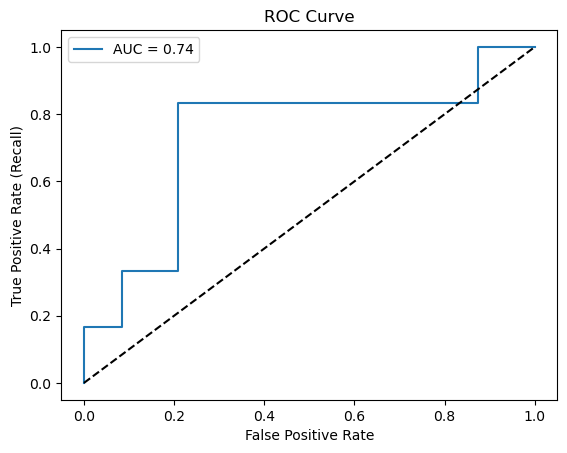

AUC Score: 0.7361


In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")


##### Precision–Recall Curve

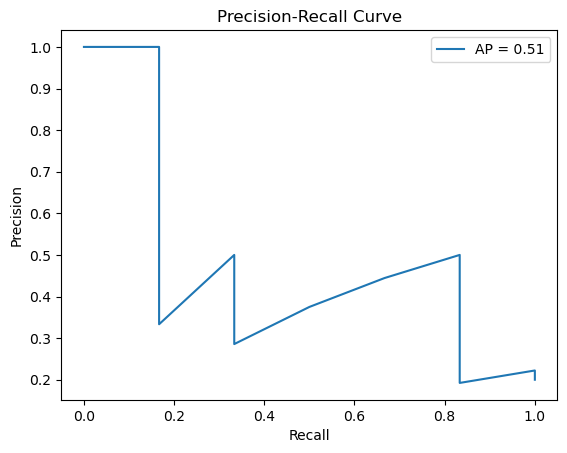

Average Precision Score: 0.5069


In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f"AP = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")


##### Threshold tuning

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\nThreshold: {threshold}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    return acc, prec, rec, f1

# Run for thresholds 0.3, 0.5, 0.7
metrics = {}
for t in [0.3, 0.5, 0.7]:
    metrics[t] = evaluate_threshold(y_test, y_prob, t)



Threshold: 0.3
Confusion Matrix:
 [[15  9]
 [ 1  5]]
Accuracy: 0.6667, Precision: 0.3571, Recall: 0.8333, F1: 0.5000

Threshold: 0.5
Confusion Matrix:
 [[19  5]
 [ 1  5]]
Accuracy: 0.8000, Precision: 0.5000, Recall: 0.8333, F1: 0.6250

Threshold: 0.7
Confusion Matrix:
 [[22  2]
 [ 5  1]]
Accuracy: 0.7667, Precision: 0.3333, Recall: 0.1667, F1: 0.2222


##### ROC Curve Visualization

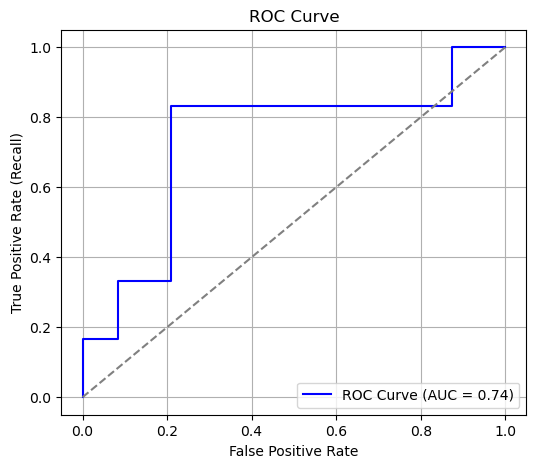

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


##### Precision–Recall Curve Visualization

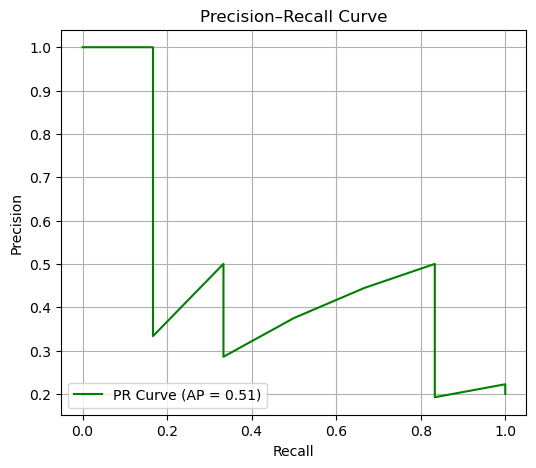

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# PR curve values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='green', label=f'PR Curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()
